# Phase 1 — Lesson 4
# Time Series Components: Level, Trend, Seasonality, and Noise
## EUR/USD H4 Practice Notebook

Default EUR/USD project dataset: `Data/EURUSD_H4.csv`

### Objectives
- Understand Level, Trend, Seasonality, and Noise.
- Identify them visually in EUR/USD H4 data.
- Distinguish Trend vs Seasonality and Seasonality vs Noise.
- Practice using the real EUR/USD dataset.

> This lesson does not use smoothing, rolling averages, decomposition, stationarity, or forecasting models.

## 1. The four components

$$
\text{Time Series} = \text{Level} + \text{Trend} + \text{Seasonality} + \text{Noise}
$$

A common symbolic form is:

$$
Y_t = L_t + T_t + S_t + \varepsilon_t
$$

- **Level**: typical value around which the series moves.
- **Trend**: general long-term direction.
- **Seasonality**: pattern that repeats at a regular interval.
- **Noise**: irregular movement that does not repeat predictably.

## 2. Import libraries

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

## 3. Load the default EUR/USD H4 dataset

In [5]:
eurusd = pd.read_csv(
    "Data/EURUSD_H4.csv",
    parse_dates=["DateTime"],
    index_col="DateTime"
)

eurusd = eurusd.sort_index()

eurusd.head()

,Open,High,Low,Close,Volume
DateTime,,,,,
2008-12-31 20:00:00+00:00,1.39658,1.39945,1.39574,1.39746,57197.00
2009-01-01 00:00:00+00:00,1.39734,1.39754,1.39672,1.39702,38071.80
2009-01-01 04:00:00+00:00,1.39716,1.39740,1.39663,1.39700,67849.25
2009-01-01 08:00:00+00:00,1.39708,1.40370,1.39700,1.40367,128442.75
2009-01-01 12:00:00+00:00,1.40346,1.40707,1.40346,1.40682,128985.65


## 4. Quick data check

In [6]:
print(f"First timestamp: {eurusd.index.min()}")
print(f"Last timestamp : {eurusd.index.max()}")
print(f"Rows           : {len(eurusd):,}")
print(f"Index sorted   : {eurusd.index.is_monotonic_increasing}")
print(f"Duplicates     : {eurusd.index.duplicated().sum()}")

First timestamp: 2008-12-31 20:00:00+00:00
Last timestamp : 2026-09-01 20:00:00+00:00
Rows           : 30,561
Index sorted   : True
Duplicates     : 0


# Part 1 — Level

The **level** is the typical value around which the series fluctuates during a selected period.

For a simple beginner estimate, we can use the mean Close for one month.

## 5. Level example — January 2025

In [7]:
january_2025 = eurusd.loc["2025-01"]

level = january_2025["Close"].mean()

std = january_2025["Close"].std()

print(f"Approximate January 2025 level: {level:.5f}")
print(f"Standard deviation for January 2025 level: {std:.5f}")

level_up = level + std
level_down = level - std

Approximate January 2025 level: 1.03540
Standard deviation for January 2025 level: 0.00745


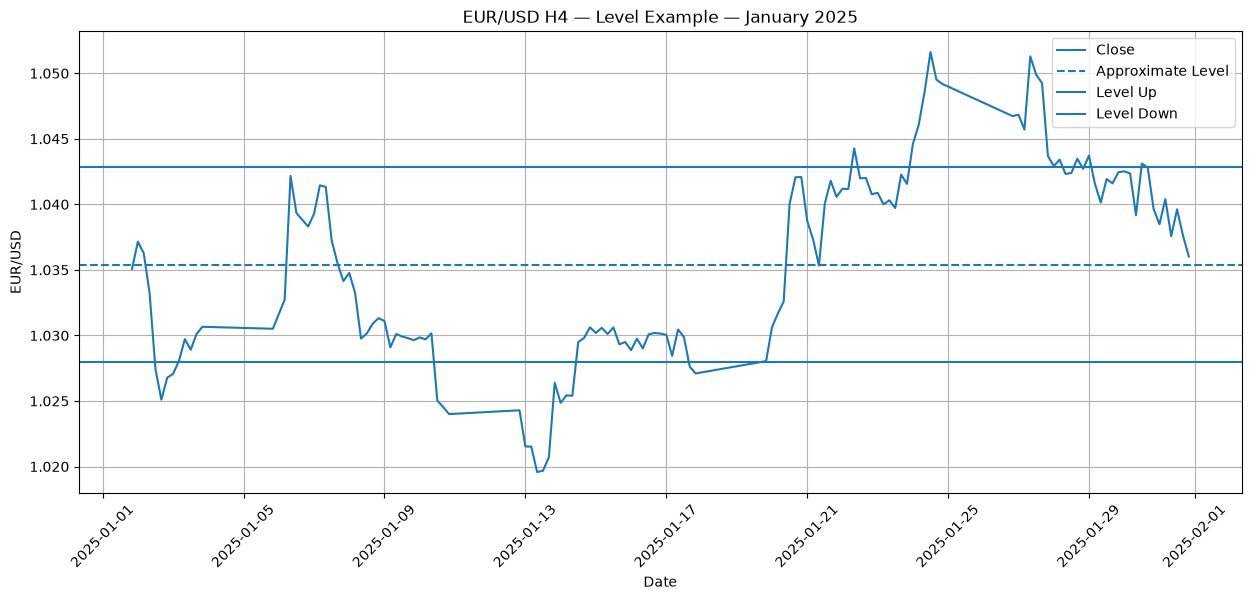

In [8]:
plt.figure(figsize=(15, 6))

plt.plot(january_2025.index, january_2025["Close"], label="Close")
plt.axhline(y=level, linestyle="--", label="Approximate Level")

plt.axhline(y=level_up, linestyle="-", label="Level Up")
plt.axhline(y=level_down, linestyle="-", label="Level Down")

plt.xlabel("Date")
plt.ylabel("EUR/USD")
plt.title("EUR/USD H4 — Level Example — January 2025")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()

### What to look for

- Does the price spend much of the month near the horizontal line?
- Does it move above and below that value?

The line gives a simple visual reference for the **level**.

# Part 2 — Trend

A **trend** is the general direction of a series over time.

- **Uptrend**: generally moves higher.
- **Downtrend**: generally moves lower.
- **No obvious trend**: no clear overall direction.

Trend does **not** mean every observation moves in the same direction.

## 6. Visual trend example — 2025

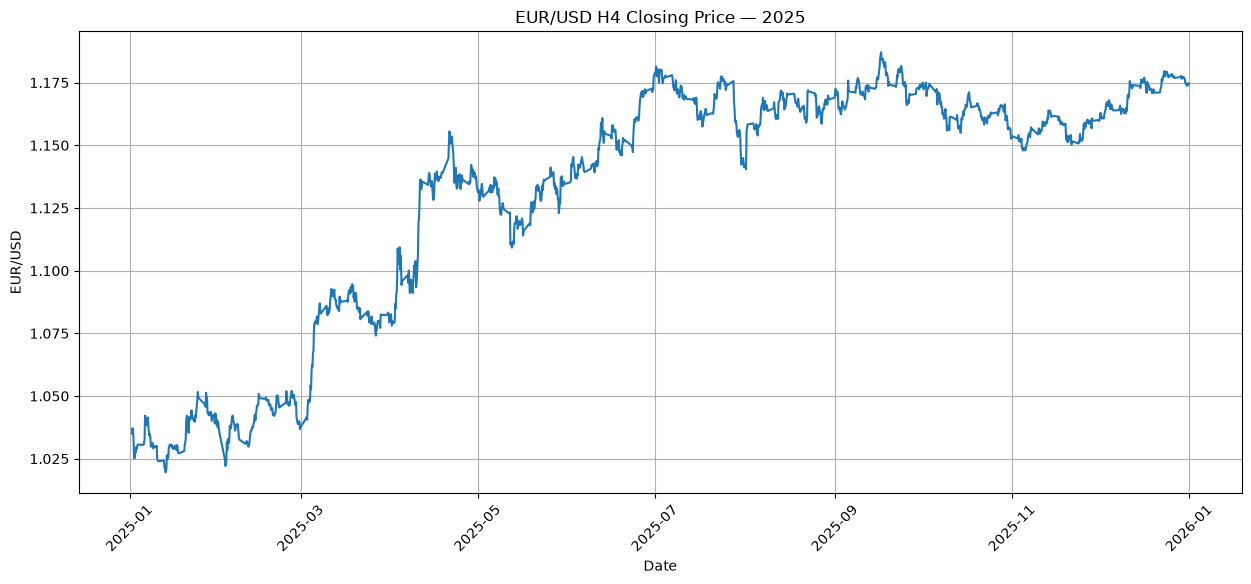

In [9]:
eurusd_2025 = eurusd.loc["2025"]

plt.figure(figsize=(15, 6))
plt.plot(eurusd_2025.index, eurusd_2025["Close"])
plt.xlabel("Date")
plt.ylabel("EUR/USD")
plt.title("EUR/USD H4 Closing Price — 2025")
plt.xticks(rotation=45)
plt.grid()
plt.show()

### Ask yourself

1. Is the general direction upward?
2. Is it downward?
3. Or is there no obvious overall direction?

Focus on the big picture rather than every H4 movement.

## 7. Beginning vs end — descriptive check

In [10]:
first_close = eurusd_2025["Close"].iloc[0]
last_close = eurusd_2025["Close"].iloc[-1]

print(f"First Close in 2025: {first_close:.5f}")
print(f"Last Close in 2025 : {last_close:.5f}")

if last_close > first_close:
    print("End value is above the beginning value.")
elif last_close < first_close:
    print("End value is below the beginning value.")
else:
    print("Beginning and ending values are equal.")

First Close in 2025: 1.03507
Last Close in 2025 : 1.17455
End value is above the beginning value.


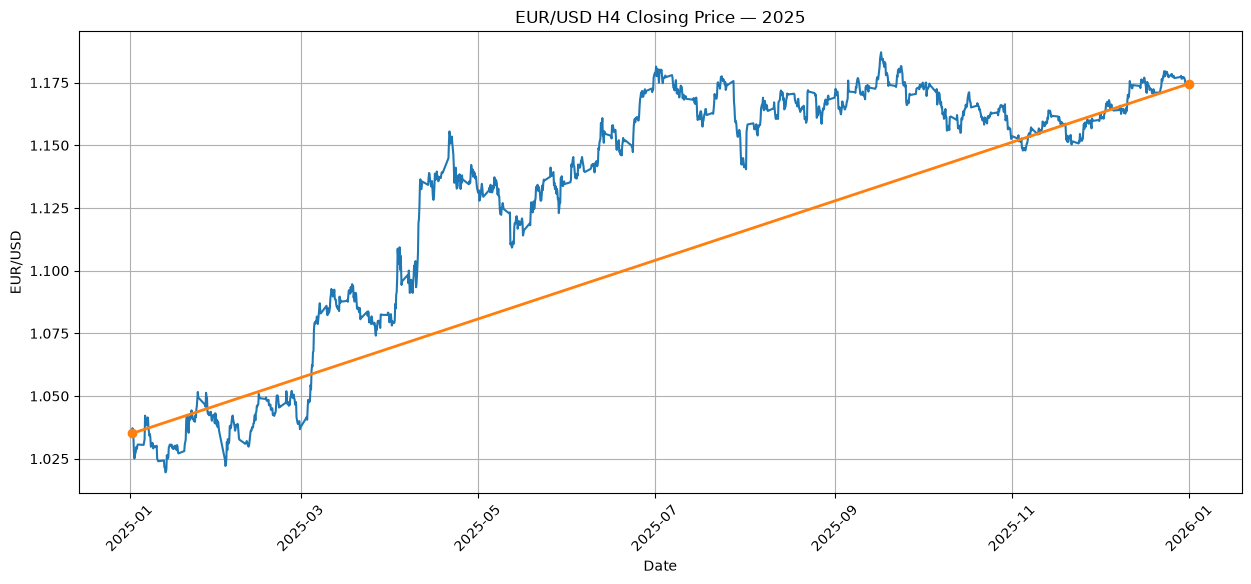

In [11]:
first_date = eurusd_2025.index[0]
last_date = eurusd_2025.index[-1]

first_close = eurusd_2025["Close"].iloc[0]
last_close = eurusd_2025["Close"].iloc[-1]

eurusd_2025 = eurusd.loc["2025"]

plt.figure(figsize=(15, 6))
plt.plot(eurusd_2025.index, eurusd_2025["Close"])

plt.plot(
    [first_date, last_date],
    [first_close, last_close],
    marker="o",
    linewidth=2
)

plt.xlabel("Date")
plt.ylabel("EUR/USD")
plt.title("EUR/USD H4 Closing Price — 2025")
plt.xticks(rotation=45)
plt.grid()
plt.show()

> Comparing first and last values is only a supporting descriptive check. Always inspect the full chart before describing a trend.

# Part 3 — Seasonality

**Seasonality** is a pattern that repeats at a regular interval.

For EUR/USD H4 data, the price itself may not show a simple repeating daily pattern. A useful beginner exploration is to examine whether **market activity** changes repeatedly by H4 candle hour.

We will use the candle High-Low range as a simple activity measure.

## 8. Create candle range

$$
\text{Range} = \text{High} - \text{Low}
$$

In [12]:
eurusd["Range"] = eurusd["High"] - eurusd["Low"]

eurusd[["High", "Low", "Range"]].head()

,High,Low,Range
DateTime,,,
2008-12-31 20:00:00+00:00,1.39945,1.39574,0.00371
2009-01-01 00:00:00+00:00,1.39754,1.39672,0.00082
2009-01-01 04:00:00+00:00,1.39740,1.39663,0.00077
2009-01-01 08:00:00+00:00,1.40370,1.39700,0.00670
2009-01-01 12:00:00+00:00,1.40707,1.40346,0.00361


## 9. Average H4 range by candle hour

In [13]:
hourly_range = eurusd.groupby(eurusd.index.hour)["Range"].mean()

hourly_range

DateTime
0     0.002468
4     0.003125
8     0.004001
12    0.005305
16    0.003441
20    0.001866
Name: Range, dtype: float64

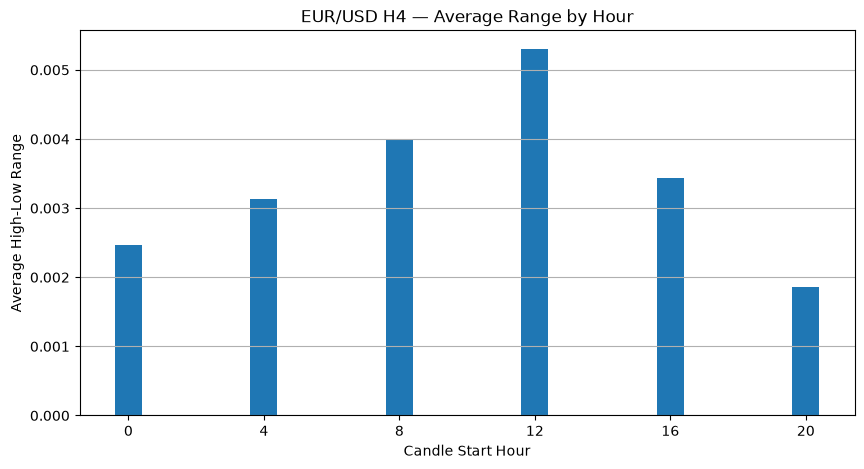

In [14]:
plt.figure(figsize=(10, 5))
plt.bar(hourly_range.index, hourly_range.values)
plt.xlabel("Candle Start Hour")
plt.ylabel("Average High-Low Range")
plt.title("EUR/USD H4 — Average Range by Hour")
plt.xticks(hourly_range.index)
plt.grid(axis="y")
plt.show()

### Interpretation

If some H4 hours repeatedly have larger average ranges than others, there may be a recurring **intraday activity pattern**.

That is different from saying the price itself repeats every day.

## 10. Average range by weekday

In [15]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]

day_range = eurusd.groupby(eurusd.index.day_name())["Range"].mean()
day_range = day_range.reindex(day_order)

day_range

DateTime
Monday       0.003293
Tuesday      0.003554
Wednesday    0.003694
Thursday     0.003853
Friday       0.003564
Name: Range, dtype: float64

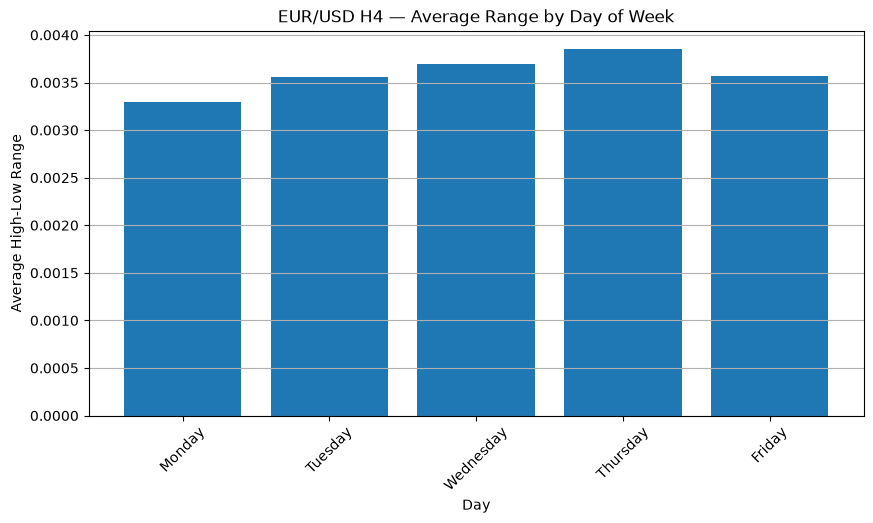

In [16]:
plt.figure(figsize=(10, 5))
plt.bar(day_range.index, day_range.values)
plt.xlabel("Day")
plt.ylabel("Average High-Low Range")
plt.title("EUR/USD H4 — Average Range by Day of Week")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

> A historical seasonal pattern does not guarantee that the pattern will continue in the future. Financial-market behavior changes over time.

# Part 4 — Noise

**Noise** is irregular short-term movement that does not form a clear repeating pattern.

Financial price series naturally contain a lot of short-term irregular movement.

## 11. Visual noise example — one trading week

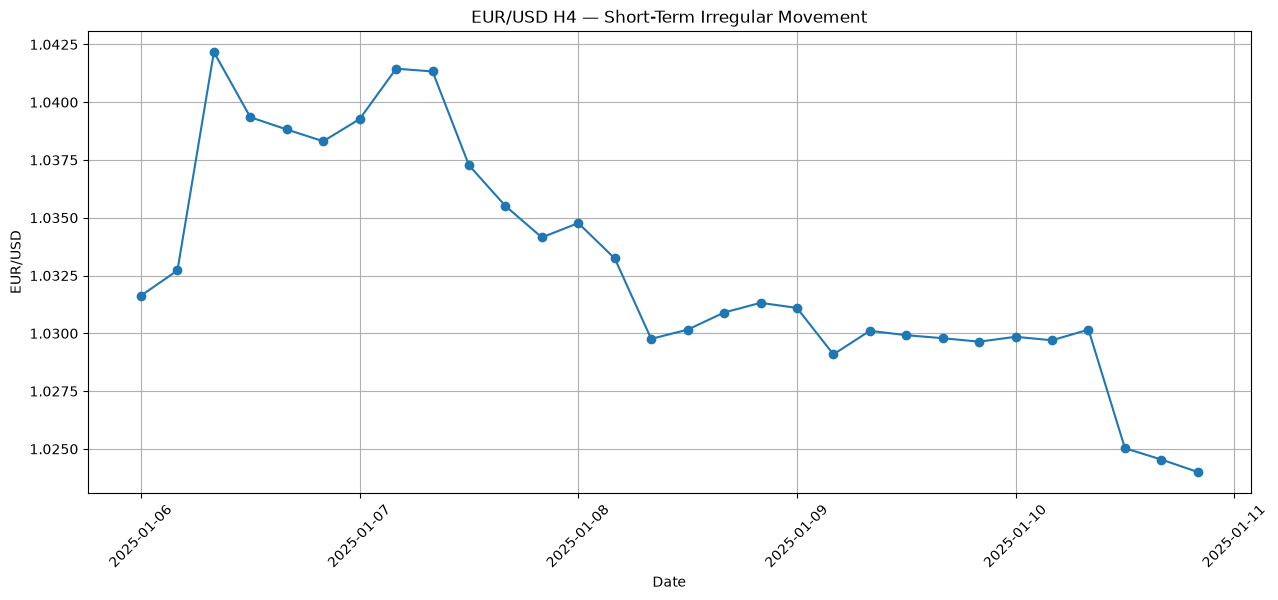

In [17]:
eurusd_week = eurusd.loc["2025-01-06":"2025-01-10"]

plt.figure(figsize=(15, 6))
plt.plot(eurusd_week.index, eurusd_week["Close"], marker="o")
plt.xlabel("Date")
plt.ylabel("EUR/USD")
plt.title("EUR/USD H4 — Short-Term Irregular Movement")
plt.xticks(rotation=45)
plt.grid()
plt.show()

### What to look for

Short-term movements may go up, down, then reverse again. These irregular fluctuations are part of what we call **noise**.

Do not assume every small movement is a meaningful trend.

# Trend vs Seasonality

| Trend | Seasonality |
|---|---|
| General long-term direction | Repeating pattern |
| Does not need to repeat | Repeats at a regular interval |
| Example: generally rising for months | Example: activity repeatedly higher at certain hours |

# Seasonality vs Noise

| Seasonality | Noise |
|---|---|
| Repeats | Irregular |
| Has a time-based pattern | No reliable repeating pattern |
| Linked to a regular interval | Random-looking short-term variation |

# 12. Four questions to ask

### Level
Around what value does the series usually move?

### Trend
Is the general direction up, down, or unclear?

### Seasonality
Is there a pattern that repeats at a regular interval?

### Noise
Which movements appear irregular and non-repeating?

# Practice Exercises

## Exercise 1 — Level

Use **March 2025**.

1. Filter March 2025.
2. Calculate mean Close.
3. Plot Close.
4. Add a horizontal line for the approximate level.

In [18]:
# Write your Exercise 1 code here
# Filter March 2025.
eurusd_202503 = eurusd.loc['2025-03']
eurusd_202503

,Open,High,Low,Close,Volume,Range
DateTime,,,,,,
2025-03-02 20:00:00+00:00,1.04032,1.04208,1.03992,1.04119,8691.64,0.00216
2025-03-03 00:00:00+00:00,1.04119,1.04231,1.04021,1.04168,27710.98,0.00210
2025-03-03 04:00:00+00:00,1.04167,1.04203,1.04018,1.04054,24526.36,0.00185
2025-03-03 08:00:00+00:00,1.04053,1.04579,1.03883,1.04524,34150.17,0.00696
2025-03-03 12:00:00+00:00,1.04525,1.05036,1.04525,1.04845,50413.60,0.00511
...,...,...,...,...,...,...
2025-03-31 04:00:00+00:00,1.08328,1.08492,1.08206,1.08313,31574.18,0.00286
2025-03-31 08:00:00+00:00,1.08313,1.08340,1.08054,1.08190,33219.82,0.00286
2025-03-31 12:00:00+00:00,1.08192,1.08212,1.07838,1.07940,49078.30,0.00374


In [19]:
# Calculate mean Close.
mean_level = eurusd_202503['Close'].mean()
mean_level


np.float64(1.0805129007633587)

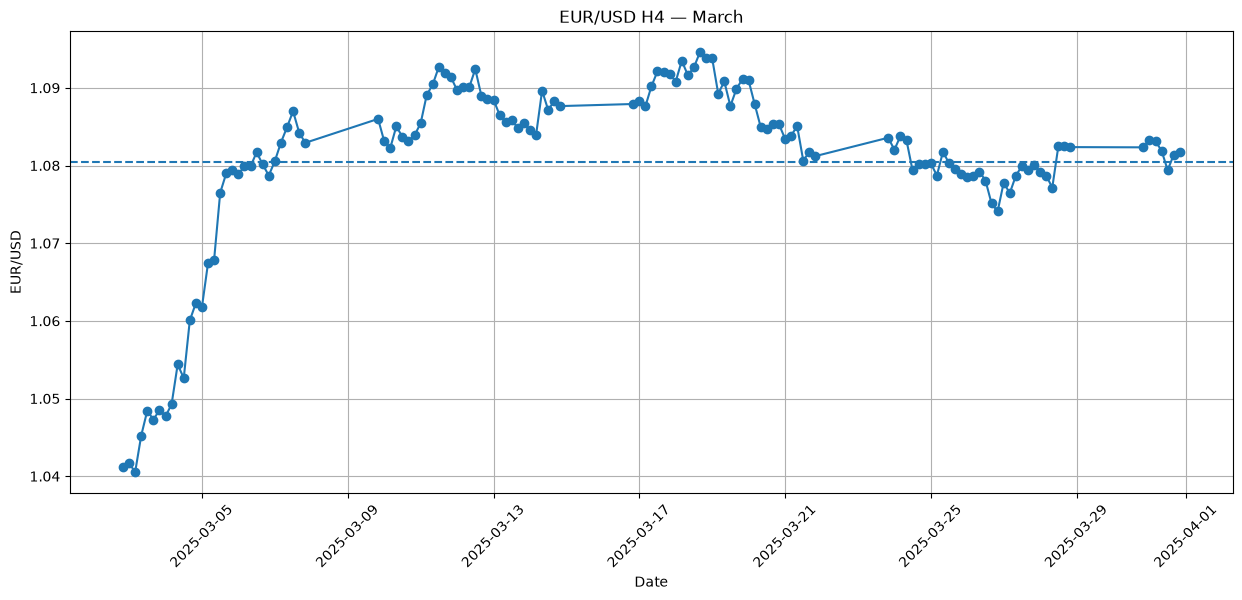

In [20]:
plt.figure(figsize=(15, 6))
plt.plot(eurusd_202503.index, eurusd_202503["Close"], marker="o")

plt.axhline(y=mean_level, linestyle="--", label="Approximate Level")

plt.xlabel("Date")
plt.ylabel("EUR/USD")
plt.title("EUR/USD H4 — March")
plt.xticks(rotation=45)
plt.grid()
plt.show()

## Exercise 2 — Trend

Plot EUR/USD Close for **2024** and classify it visually as:

- Uptrend
- Downtrend
- No obvious trend

In [31]:
# Write your Exercise 2 code here
eurusd_2024 = eurusd.loc['2024']
print(eurusd_2024.head())
mean_2024 = eurusd_2024['Close'].mean()
print(f'The Mean Level is {mean_2024}')

                              Open     High      Low    Close    Volume  \
DateTime                                                                  
2024-01-01 20:00:00+00:00  1.10427  1.10447  1.10356  1.10365   3923.96   
2024-01-02 00:00:00+00:00  1.10366  1.10432  1.10176  1.10245  24509.62   
2024-01-02 04:00:00+00:00  1.10245  1.10380  1.10151  1.10153  30174.74   
2024-01-02 08:00:00+00:00  1.10156  1.10387  1.09665  1.09690  70041.65   
2024-01-02 12:00:00+00:00  1.09691  1.09717  1.09410  1.09435  86422.11   

                             Range  
DateTime                            
2024-01-01 20:00:00+00:00  0.00091  
2024-01-02 00:00:00+00:00  0.00256  
2024-01-02 04:00:00+00:00  0.00229  
2024-01-02 08:00:00+00:00  0.00722  
2024-01-02 12:00:00+00:00  0.00307  
The Mean Level is 1.0819966367574259


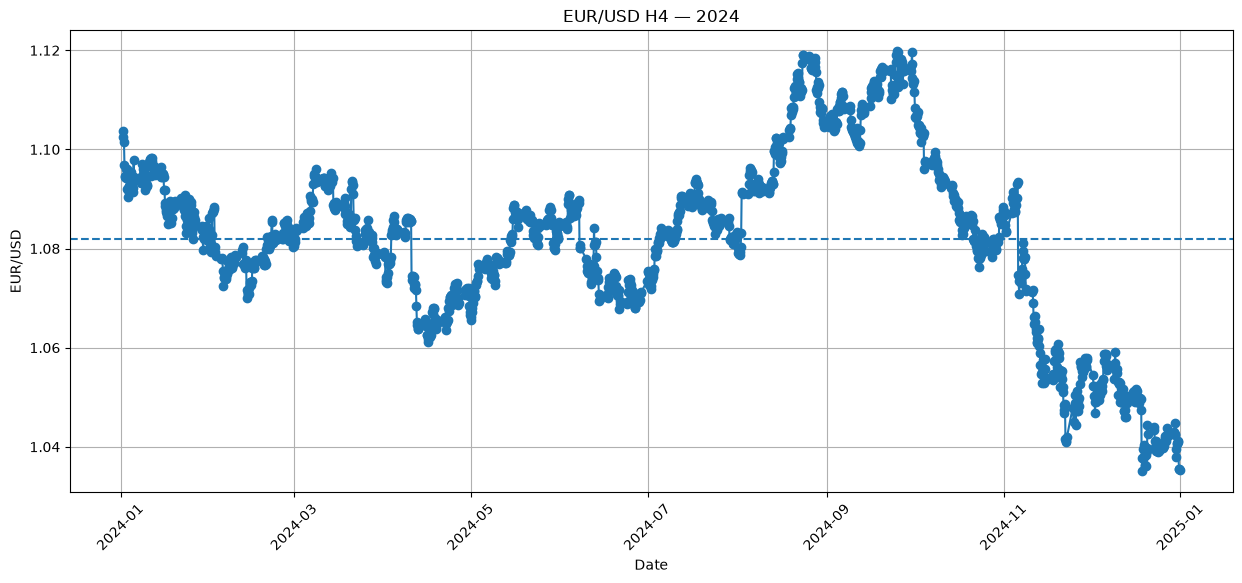

In [32]:
plt.figure(figsize=(15, 6))
plt.plot(eurusd_2024.index, eurusd_2024["Close"], marker="o")

plt.axhline(y=mean_2024, linestyle="--", label="Approximate Level")

plt.xlabel("Date")
plt.ylabel("EUR/USD")
plt.title("EUR/USD H4 — 2024")
plt.xticks(rotation=45)
plt.grid()
plt.show()

## Exercise 3 — Seasonality

Calculate average `Range` by H4 candle hour.

Answer:
1. Which hour has the largest average range?
2. Which hour has the smallest average range?
3. Is activity identical across all H4 periods?

In [42]:
# Write your Exercise 3 code here
hourly_range = eurusd.groupby(
    eurusd.index.hour
)["Range"].mean()

print(hourly_range)

DateTime
0     0.002468
4     0.003125
8     0.004001
12    0.005305
16    0.003441
20    0.001866
Name: Range, dtype: float64


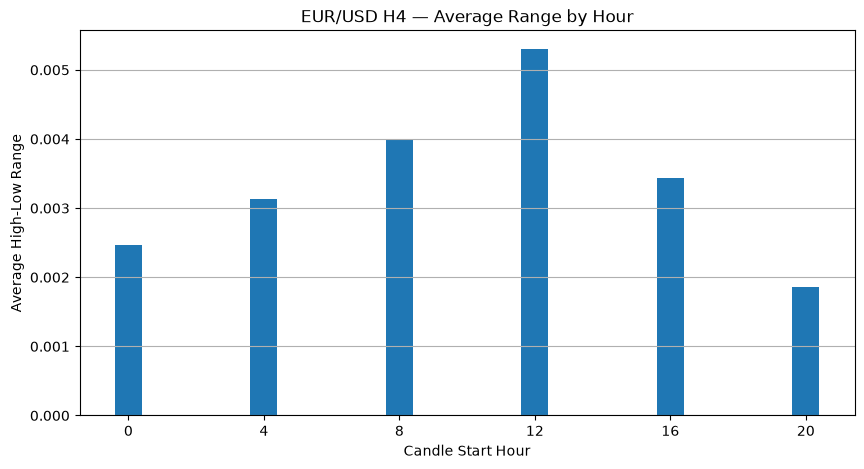

In [43]:
plt.figure(figsize=(10, 5))

plt.bar(
    hourly_range.index,
    hourly_range.values
)

plt.xlabel("Candle Start Hour")
plt.ylabel("Average High-Low Range")
plt.title("EUR/USD H4 — Average Range by Hour")
plt.xticks(hourly_range.index)
plt.grid(axis="y")

plt.show()

## Exercise 4 — Noise

Choose one trading week in 2025, plot Close with markers, and describe the irregular short-term movement you observe.

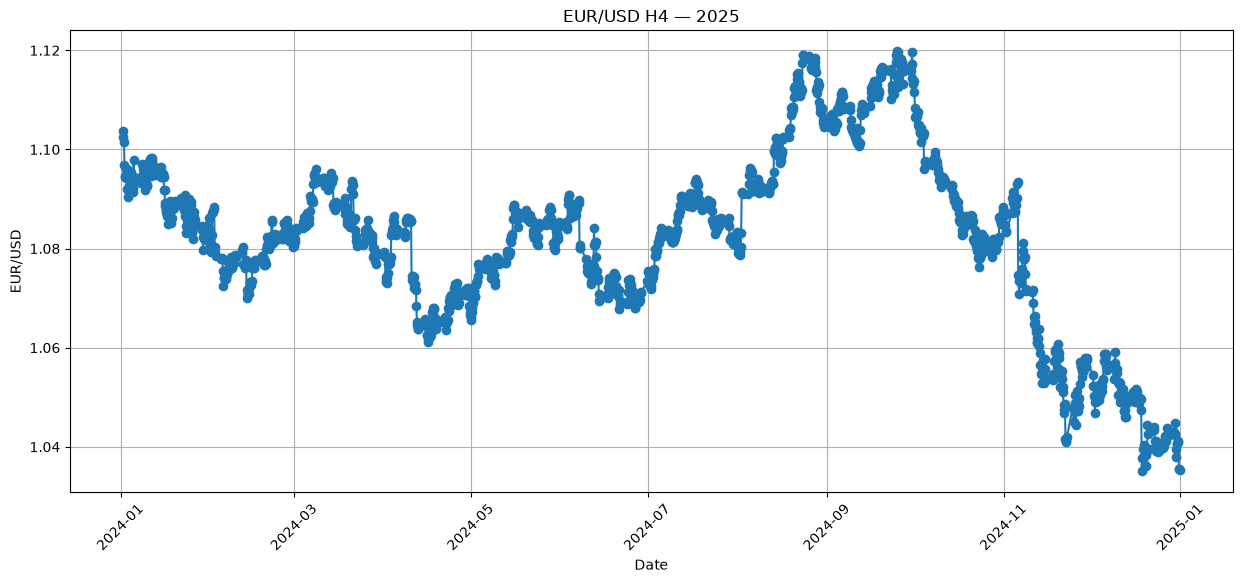

In [45]:
# Write your Exercise 4 code here
eurusd_2025 = eurusd.loc['2025']
# print(eurusd_2024.head())


plt.figure(figsize=(15, 6))
plt.plot(eurusd_2024.index, eurusd_2024["Close"], marker="o")

# plt.axhline(y=mean_2024, linestyle="--", label="Approximate Level")

plt.xlabel("Date")
plt.ylabel("EUR/USD")
plt.title("EUR/USD H4 — 2025")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# Final Practice Task

Choose **one month in 2025** and perform a short component analysis.

### Level
- Calculate average Close.
- Plot Close with a horizontal level line.

### Trend
State: Uptrend, Downtrend, or No obvious trend.

### Seasonality
Calculate average `Range` by H4 candle hour.

### Noise
Identify irregular short-term movement.

Finally write one conclusion for each component.

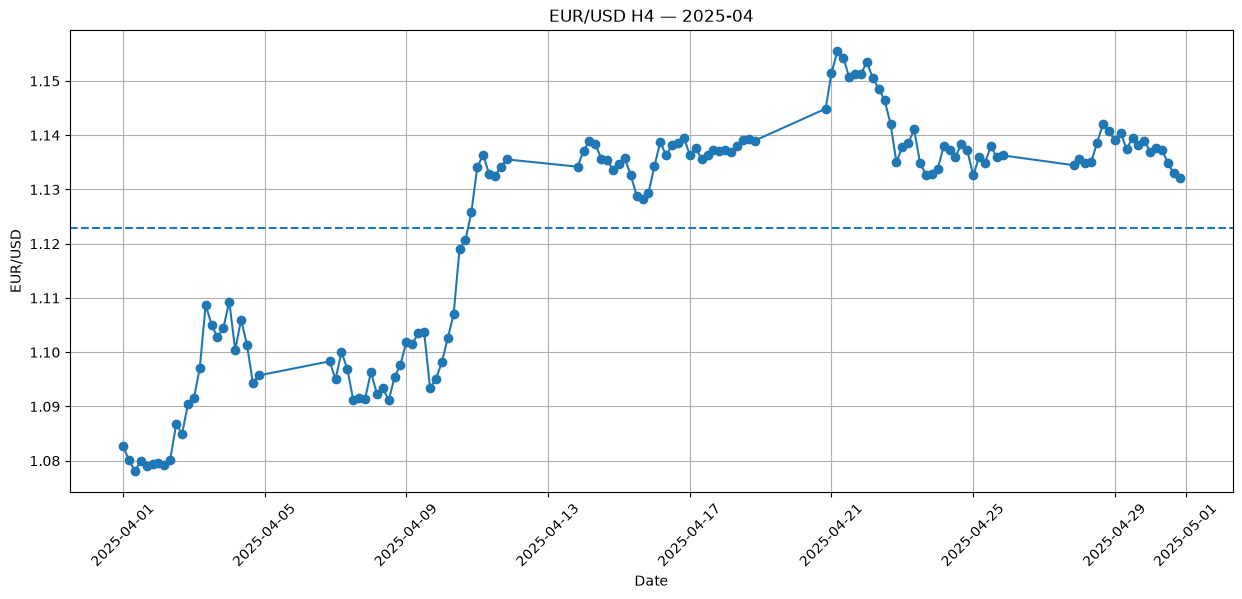

In [48]:
# Final Practice Task

# Choose one month in 2025
# Example:
# practice_month = eurusd.loc["2025-03"]

practice_month = eurusd.loc["2025-04"]

# 1. LEVEL
practice_month_mean = practice_month['Close'].mean()

plt.figure(figsize=(15, 6))
plt.plot(practice_month.index, practice_month["Close"], marker="o")

plt.axhline(y=practice_month_mean, linestyle="--", label="Approximate Level")

plt.xlabel("Date")
plt.ylabel("EUR/USD")
plt.title("EUR/USD H4 — 2025-04")
plt.xticks(rotation=45)
plt.grid()
plt.show()
# 2. TREND


# 3. SEASONALITY


# 4. NOISE


## Final conclusions

**Level:**  

**Trend:**  

**Seasonality:**  

**Noise:**  

# Lesson 4 Cheat Sheet

## Level
Typical value around which the series moves.

```python
level = data["Close"].mean()
```

## Trend
General direction over time:
- Uptrend
- Downtrend
- No obvious trend

## Seasonality
A pattern that repeats at a regular interval.

```python
eurusd["Range"] = eurusd["High"] - eurusd["Low"]
eurusd.groupby(eurusd.index.hour)["Range"].mean()
```

## Noise
Irregular short-term movement that does not repeat predictably.

## Main equation

$$
\text{Time Series} = \text{Level} + \text{Trend} + \text{Seasonality} + \text{Noise}
$$